## Simple sentiment analysis with IMDb DataSet

Loosely following https://developers.google.com/machine-learning/guides/text-classification


In [ ]:
!wget http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz \
    -O data/aclImdb_v1.tar.gz
!gunzip data/aclImdb_v1.tar.gz
!tar -xvf data/aclImdb_v1.tar -C data

In [17]:
import os
import random
import numpy as np

def load_imdb_sentiment_analysis_dataset(data_path, seed=123):
    """Loads the IMDb movie reviews sentiment analysis dataset.

    # Arguments
        data_path: string, path to the data directory.
        seed: int, seed for randomizer.

    # Returns
        A tuple of training and validation data.
        Number of training samples: 25000
        Number of test samples: 25000
        Number of categories: 2 (0 - negative, 1 - positive)

    # References
        Mass et al., http://www.aclweb.org/anthology/P11-1015

        Download and uncompress archive from:
        http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
    """
    imdb_data_path = os.path.join(data_path, 'aclImdb')

    # Load the training data
    train_texts = []
    train_labels = []
    for category in ['pos', 'neg']:
        train_path = os.path.join(imdb_data_path, 'train', category)
        for fname in sorted(os.listdir(train_path)):
            if fname.endswith('.txt'):
                with open(os.path.join(train_path, fname)) as f:
                    train_texts.append(f.read())
                train_labels.append(0 if category == 'neg' else 1)

    # Load the validation data.
    test_texts = []
    test_labels = []
    for category in ['pos', 'neg']:
        test_path = os.path.join(imdb_data_path, 'test', category)
        for fname in sorted(os.listdir(test_path)):
            if fname.endswith('.txt'):
                with open(os.path.join(test_path, fname)) as f:
                    test_texts.append(f.read())
                test_labels.append(0 if category == 'neg' else 1)

    # Shuffle the training data and labels.
    random.seed(seed)
    random.shuffle(train_texts)
    random.seed(seed)
    random.shuffle(train_labels)

    return ((train_texts, np.array(train_labels)),
            (test_texts, np.array(test_labels)))

In [19]:
dataset = load_imdb_sentiment_analysis_dataset('data')

### Explore DataSet
Find things such as...
Number of samples: Total number of examples you have in the data.
Number of classes: Total number of topics or categories in the data.
Number of samples per class: Number of samples per class (topic/category). In a balanced dataset, all classes will have a similar number of samples; in an imbalanced dataset, the number of samples in each class will vary widely.
Number of words per sample: Median number of words in one sample.
Frequency distribution of words: Distribution showing the frequency (number of occurrences) of each word in the dataset.
Distribution of sample length: Distribution showing the number of words per sample in the dataset.

In [21]:
print('Train dataset size', len(dataset[0][0]))
print('Test dataset size', len(dataset[1][0]))

Train dataset size 25000
Test dataset size 25000


In [28]:
train_samples = dataset[0][0]
train_labels = dataset[0][1]
print(f'Number of samples: {len(train_samples)}')
classes = np.unique(train_labels, return_counts=True)
print('# of classes:', len(classes))
for label, count in classes:
    print(f'Label {label} occurs {count} times')


Number of samples: 25000
# of classes: 2
Label 0 occurs 1 times
Label 12500 occurs 12500 times


In [29]:
num_words = [len(s.split()) for s in train_samples]
median = np.median(num_words)
print(f'Median word count for sample is {median}')

Median word count for sample is 174.0


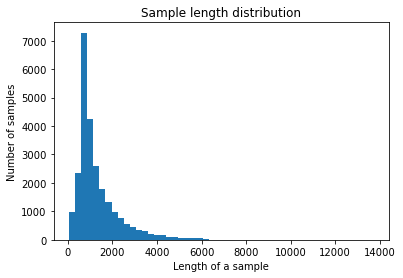

In [30]:
import matplotlib.pyplot as plt

plt.hist([len(s) for s in train_samples], 50)
plt.xlabel('Length of a sample')
plt.ylabel('Number of samples')
plt.title('Sample length distribution')
plt.show()


In [40]:
from itertools import chain

all_words = list(chain(*[s.split() for s in train_samples]))

In [41]:
len(all_words)

5844680

In [42]:
plt.hist(all_words, 5)
plt.show()

/Users/emmamatsubara/miniconda3/envs/ml/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 150 (\x96) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


ValueError: 
$$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

<Figure size 432x288 with 1 Axes>

In [43]:
arr = np.array(all_words)
unique = np.unique(arr, return_counts=True)
unique


(array(['\x08\x08\x08\x08A', '\x10own', '!', ..., '₤100', '₤250,000',
        '\uf0b7'], dtype='<U77'),
 array([  1,   1, 803, ...,   1,   1,   2]))